## Step 1: Import Libraries

In [1]:
import os
import json
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss, classification_report, confusion_matrix
from xgboost import XGBClassifier

## Step 2: Load Dataset

In [2]:
data_path = r'd:\B.Tech\Semester 04\01 Machine Learning\LabAssginment\dataset\sleep_health_dataset.csv'
df = pd.read_csv(data_path)

print('Dataset shape:', df.shape)
display(df.head())

target_column = 'sleep_disorder_risk'
print(df[target_column].value_counts())

Dataset shape: (100000, 32)


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


sleep_disorder_risk
Healthy     54156
Mild        33479
Moderate     8299
Severe       4066
Name: count, dtype: int64


## Step 3: Prepare Data

In [3]:
X = df.drop(columns=[target_column, 'person_id'])
y_text = df[target_column].astype(str)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)
class_names = list(label_encoder.classes_)

X = pd.get_dummies(X, drop_first=False)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=21,
    stratify=y
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Classes:', class_names)

X_train shape: (80000, 66)
X_test shape: (20000, 66)
Classes: ['Healthy', 'Mild', 'Moderate', 'Severe']


## Step 4: Train XGBoost Model

In [4]:
model = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    num_class=len(class_names),
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=21,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

print('Model training completed')

Model training completed


## Step 5: Check Model Performance

In [5]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
loss = log_loss(y_test, y_prob)

print('Accuracy:', round(accuracy, 4))
print('Weighted Precision:', round(precision, 4))
print('Weighted Recall:', round(recall, 4))
print('Weighted F1 Score:', round(f1, 4))
print('Weighted ROC AUC (OvR):', round(roc_auc, 4))
print('Log Loss:', round(loss, 4))

print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, target_names=class_names, digits=4, zero_division=0))

Accuracy: 0.9525
Weighted Precision: 0.9511
Weighted Recall: 0.9525
Weighted F1 Score: 0.9514
Weighted ROC AUC (OvR): 0.9969
Log Loss: 0.1408

Classification Report:

              precision    recall  f1-score   support

     Healthy     0.9979    0.9982    0.9980     10831
        Mild     0.9357    0.9668    0.9510      6696
    Moderate     0.7439    0.6928    0.7174      1660
      Severe     0.8773    0.7565    0.8124       813

    accuracy                         0.9525     20000
   macro avg     0.8887    0.8536    0.8697     20000
weighted avg     0.9511    0.9525    0.9514     20000



## Step 6: Plot Confusion Matrix

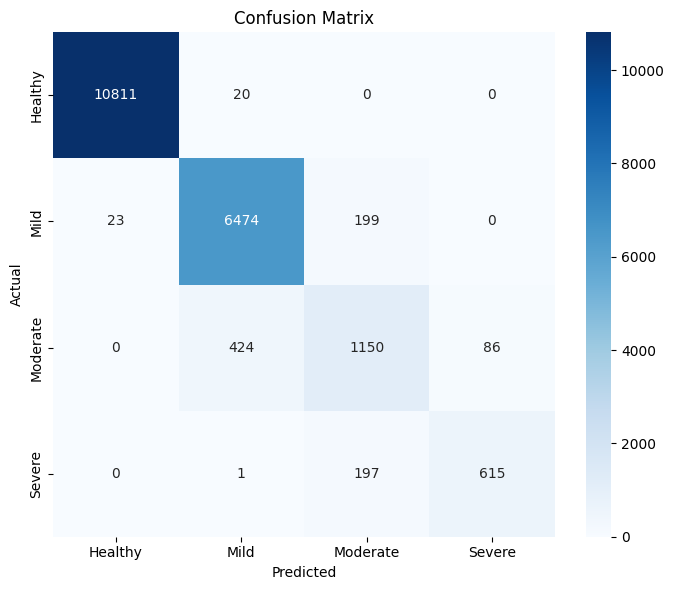

In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

## Step 7: Save Model and Metrics

In [7]:
base_output = r'd:\B.Tech\Semester 04\01 Machine Learning\LabAssginment\outputs\Sleep_Health_And_Daily_Performance'
model_dir = os.path.join(base_output, 'model')
metrics_dir = os.path.join(base_output, 'metrics')

os.makedirs(model_dir, exist_ok=True)
os.makedirs(metrics_dir, exist_ok=True)

model_path = os.path.join(model_dir, 'model.joblib')
columns_path = os.path.join(model_dir, 'feature_columns.json')
labels_path = os.path.join(model_dir, 'label_classes.json')
info_path = os.path.join(model_dir, 'target_info.json')
metrics_path = os.path.join(metrics_dir, 'final_metircs.csv')
predictions_path = os.path.join(metrics_dir, 'prediction.csv')

joblib.dump(model, model_path)
with open(columns_path, 'w', encoding='utf-8') as f:
    json.dump(list(X.columns), f, indent=2)
with open(labels_path, 'w', encoding='utf-8') as f:
    json.dump(class_names, f, indent=2)
with open(info_path, 'w', encoding='utf-8') as f:
    json.dump({'target_col': target_column, 'model_name': 'XGBClassifier'}, f, indent=2)

final_metrics = pd.DataFrame([
    {'metric': 'accuracy', 'value': accuracy},
    {'metric': 'precision_weighted', 'value': precision},
    {'metric': 'recall_weighted', 'value': recall},
    {'metric': 'f1_weighted', 'value': f1},
    {'metric': 'roc_auc_ovr_weighted', 'value': roc_auc},
    {'metric': 'log_loss', 'value': loss}
])
final_metrics.to_csv(metrics_path, index=False)

actual_labels = [class_names[i] for i in y_test]
pred_labels = [class_names[i] for i in y_pred]
prediction_df = pd.DataFrame({'Actual': actual_labels, 'Predicted': pred_labels})
prediction_df.to_csv(predictions_path, index=False)

print('Saved model:', model_path)
print('Saved columns:', columns_path)
print('Saved labels:', labels_path)
print('Saved target info:', info_path)
print('Saved metrics:', metrics_path)
print('Saved predictions:', predictions_path)

Saved model: d:\B.Tech\Semester 04\01 Machine Learning\LabAssginment\outputs\Sleep_Health_And_Daily_Performance\model\model.joblib
Saved columns: d:\B.Tech\Semester 04\01 Machine Learning\LabAssginment\outputs\Sleep_Health_And_Daily_Performance\model\feature_columns.json
Saved labels: d:\B.Tech\Semester 04\01 Machine Learning\LabAssginment\outputs\Sleep_Health_And_Daily_Performance\model\label_classes.json
Saved target info: d:\B.Tech\Semester 04\01 Machine Learning\LabAssginment\outputs\Sleep_Health_And_Daily_Performance\model\target_info.json
Saved metrics: d:\B.Tech\Semester 04\01 Machine Learning\LabAssginment\outputs\Sleep_Health_And_Daily_Performance\metrics\final_metircs.csv
Saved predictions: d:\B.Tech\Semester 04\01 Machine Learning\LabAssginment\outputs\Sleep_Health_And_Daily_Performance\metrics\prediction.csv


## Step 8: Final Summary

In [8]:
summary = pd.DataFrame([
    {'Metric': 'Accuracy', 'Value': accuracy},
    {'Metric': 'Weighted Precision', 'Value': precision},
    {'Metric': 'Weighted Recall', 'Value': recall},
    {'Metric': 'Weighted F1 Score', 'Value': f1},
    {'Metric': 'Weighted ROC AUC (OvR)', 'Value': roc_auc},
    {'Metric': 'Log Loss', 'Value': loss}
])

display(summary)
print('Final model used: XGBClassifier')
print('Target column:', target_column)
print('Classes:', class_names)

,Metric,Value
0,Accuracy,0.952500
1,Weighted Precision,0.951070
2,Weighted Recall,0.952500
3,Weighted F1 Score,0.951443
4,Weighted ROC AUC (OvR),0.996892
5,Log Loss,0.140831


Final model used: XGBClassifier
Target column: sleep_disorder_risk
Classes: ['Healthy', 'Mild', 'Moderate', 'Severe']
